In [32]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

import torch.nn as nn
from torch.utils.data import DataLoader,TensorDataset
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [33]:
df = pd.read_csv("Salary_dataset.csv")
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  28 non-null     float64
 1   Salary           29 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [35]:
df[df.isna().any(axis=1)]

,YearsExperience,Salary
7,NaN,54446.0
13,4.2,NaN
16,NaN,66030.0


In [36]:
df = df.dropna(subset=['Salary'], axis=0)

In [37]:
df

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,NaN,54446.0
8,3.3,64446.0
9,3.8,57190.0


In [38]:



X = df.drop(columns=['Salary'])
y = df[['Salary']]

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessing = ColumnTransformer(transformers=[
    ('num', numeric_transformer, ['YearsExperience'])
])
X_train = preprocessing.fit_transform(X_train)
X_test = preprocessing.transform(X_test)
standard_scaler = StandardScaler()
y_train = standard_scaler.fit_transform(y_train)
y_test = standard_scaler.transform(y_test)

In [39]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train).reshape(-1, 1)
y_test = torch.FloatTensor(y_test).reshape(-1, 1)

In [40]:
y_test

tensor([[ 1.7464],
        [ 0.2979],
        [-0.6652],
        [ 1.4302],
        [-0.3892],
        [-0.6566]])

In [41]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
train_dl = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_dl = DataLoader(test_dataset, batch_size=8, shuffle=True)

In [42]:
class SimpleLinearRegression(nn.Module):
    def __init__(self, input_features:int = 1, output_features:int = 1):
        super().__init__()
        self.fc1 = nn.Linear(input_features, 10)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(10, output_features)
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

    def predict(self, x):
        with torch.no_grad():
            result =  self.forward(x)
        return result

In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

epochs = 100
losses = []
criterion = nn.MSELoss()
torch.manual_seed(42)
model = SimpleLinearRegression().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x,batch_y in train_dl:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        y_pred = model(batch_x)
        loss = criterion(y_pred,batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss/len(train_dl)
    losses.append(avg_loss)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss:.4f}")

"""
for epoch in range(num_epochs):
    optimizer.zero_grad() # 1. clear old gradients
    preds = model(x) # 2. forward pass
    loss = criterion(preds, y) # 3. compute the loss
    loss.backward() # 4. backward pass
    optimizer.step() # 5. update parameters
"""

Using device: cpu
Epoch: 1, Loss: 0.7413
Epoch: 2, Loss: 0.7062
Epoch: 3, Loss: 0.6926
Epoch: 4, Loss: 0.6561
Epoch: 5, Loss: 0.6379
Epoch: 6, Loss: 0.6190
Epoch: 7, Loss: 0.6006
Epoch: 8, Loss: 0.5811
Epoch: 9, Loss: 0.5570
Epoch: 10, Loss: 0.5221
Epoch: 11, Loss: 0.5078
Epoch: 12, Loss: 0.4914
Epoch: 13, Loss: 0.4758
Epoch: 14, Loss: 0.4475
Epoch: 15, Loss: 0.4429
Epoch: 16, Loss: 0.4229
Epoch: 17, Loss: 0.3981
Epoch: 18, Loss: 0.3912
Epoch: 19, Loss: 0.3748
Epoch: 20, Loss: 0.3620
Epoch: 21, Loss: 0.3454
Epoch: 22, Loss: 0.3350
Epoch: 23, Loss: 0.3083
Epoch: 24, Loss: 0.3033
Epoch: 25, Loss: 0.2880
Epoch: 26, Loss: 0.2755
Epoch: 27, Loss: 0.2623
Epoch: 28, Loss: 0.2594
Epoch: 29, Loss: 0.2442
Epoch: 30, Loss: 0.2357
Epoch: 31, Loss: 0.2185
Epoch: 32, Loss: 0.2147
Epoch: 33, Loss: 0.2070
Epoch: 34, Loss: 0.1910
Epoch: 35, Loss: 0.1878
Epoch: 36, Loss: 0.1764
Epoch: 37, Loss: 0.1724
Epoch: 38, Loss: 0.1636
Epoch: 39, Loss: 0.1541
Epoch: 40, Loss: 0.1510
Epoch: 41, Loss: 0.1432
Epoch: 

'\nfor epoch in range(num_epochs):\n    optimizer.zero_grad() # 1. clear old gradients\n    preds = model(x) # 2. forward pass\n    loss = criterion(preds, y) # 3. compute the loss\n    loss.backward() # 4. backward pass\n    optimizer.step() # 5. update parameters\n'

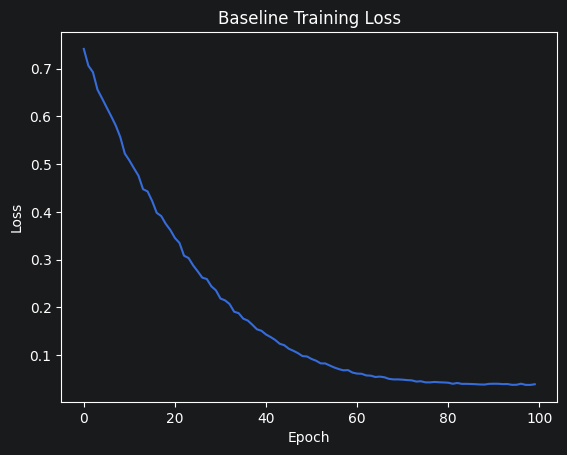

In [44]:
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline Training Loss')
plt.show()

In [45]:
updated_losses = []
torch.manual_seed(42)
updated_model = SimpleLinearRegression().to(device)
updated_optimizer = torch.optim.Adam(updated_model.parameters(), lr=0.01)

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x,batch_y in train_dl:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        updated_optimizer.zero_grad()
        y_pred = updated_model(batch_x)
        loss = criterion(y_pred,batch_y)
        loss.backward()
        updated_optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss/len(train_dl)
    updated_losses.append(avg_loss)
    print(f"Epoch: {epoch+1}, Loss: {avg_loss:.4f}")

Epoch: 1, Loss: 0.6556
Epoch: 2, Loss: 0.4567
Epoch: 3, Loss: 0.2849
Epoch: 4, Loss: 0.1630
Epoch: 5, Loss: 0.0904
Epoch: 6, Loss: 0.0489
Epoch: 7, Loss: 0.0386
Epoch: 8, Loss: 0.0450
Epoch: 9, Loss: 0.0512
Epoch: 10, Loss: 0.0562
Epoch: 11, Loss: 0.0538
Epoch: 12, Loss: 0.0483
Epoch: 13, Loss: 0.0423
Epoch: 14, Loss: 0.0381
Epoch: 15, Loss: 0.0385
Epoch: 16, Loss: 0.0384
Epoch: 17, Loss: 0.0389
Epoch: 18, Loss: 0.0393
Epoch: 19, Loss: 0.0373
Epoch: 20, Loss: 0.0388
Epoch: 21, Loss: 0.0378
Epoch: 22, Loss: 0.0371
Epoch: 23, Loss: 0.0379
Epoch: 24, Loss: 0.0374
Epoch: 25, Loss: 0.0361
Epoch: 26, Loss: 0.0360
Epoch: 27, Loss: 0.0376
Epoch: 28, Loss: 0.0362
Epoch: 29, Loss: 0.0357
Epoch: 30, Loss: 0.0367
Epoch: 31, Loss: 0.0351
Epoch: 32, Loss: 0.0383
Epoch: 33, Loss: 0.0362
Epoch: 34, Loss: 0.0353
Epoch: 35, Loss: 0.0361
Epoch: 36, Loss: 0.0355
Epoch: 37, Loss: 0.0351
Epoch: 38, Loss: 0.0365
Epoch: 39, Loss: 0.0352
Epoch: 40, Loss: 0.0369
Epoch: 41, Loss: 0.0359
Epoch: 42, Loss: 0.0389
E

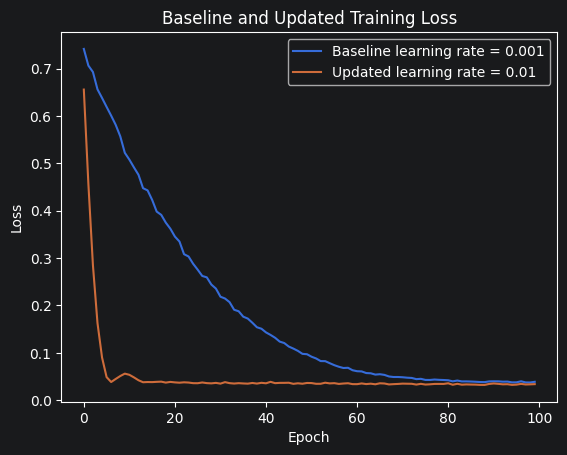

In [46]:
plt.plot(losses, label='Baseline learning rate = 0.001')
plt.plot(updated_losses, label='Updated learning rate = 0.01')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Baseline and Updated Training Loss')
plt.legend()
plt.show()

### Comparison

I updated the learning rate, it was increased from `0.001` to `0.01`. The higher learning rate makes the optimizer take larger steps when updating the model weights, so the updated model should reduce its loss faster. If the learning rate were increased too much, those larger steps could overshoot the best values and make training unstable.